# Playing with coordinates

This notebook opens up the coordinate machinery. A coordinate is not only
the ruler along an axis: it is also what tells Xdas whether that ruler can
be trusted, and it is where everything a channel number does not say gets
attached —

- how the axis is stored, and what to do when it does not increase;
- where the cable actually is, in latitude and longitude;
- what each channel is called;
- which of those can be promoted to *be* the axis.

In [1]:
import numpy as np
import pandas as pd

import xdas as xd

In [2]:
da = xd.open("outputs/singlecable.nc")
da

<xdas.DataArray (time: 37500, distance: 10000)>
VirtualSource: 715.3MB (int16)
Coordinates:
  * distance (distance): 0.000 to 153179.709
  * time (time): 2023-11-03T12:20:01.000 to 2023-11-03T12:30:00.984
    latitude (distance): [nan ... nan]
    longitude (distance): [nan ... nan]

## The three kinds of axis coordinate

An axis coordinate stores its values in whichever of three ways is cheapest:

- `DenseCoordinate` keeps every value, like a numpy array;
- `InterpCoordinate` keeps tie points and interpolates between them, so a
  long axis with a handful of gaps costs a handful of numbers;
- `SampledCoordinate` keeps a start, a length and a sampling interval per
  segment — the SEED way of describing a trace.

The two axes here are interpolated:

In [3]:
type(da["time"]).__name__, type(da["distance"]).__name__

('InterpCoordinate', 'InterpCoordinate')

### Regularity

A coordinate can also *declare* a nominal sampling interval, with a
tolerance bounding the jitter it accepts. Declaring it matters: it is what
any signal-processing routine asks for, and an interval measured end-to-end
would be quietly wrong on a gappy or jittery axis.

In [4]:
print(da["time"].isregular(), da["time"].get_sampling_interval())

True 0.016


An irregular coordinate is promoted with `to_regular(tolerance=...)`, which
we use further down. Whether it *can* be promoted depends on the timestamps
underneath — which is the next section.

## Repairing a time axis that lies

Regularity is not a formality, and a coordinate is only ever as good as the
timestamps the instrument wrote. The files below are a different acquisition
from the rest of the series: they were synchronized by NTP, which is
convenient but not very accurate, so consecutive files rarely abut to the
sample.

`tolerance` is what decides how much of that to absorb when files are linked:
any seam shorter than it counts as continuous. Passing `None` links them
exactly as they were timestamped, which is what we want here — we are looking
for the damage, not hiding it:

In [5]:
ntp = xd.open("data/ntp_sync/*.hdf5", tolerance=None)
ntp

<xdas.DataArray (time: 8750, distance: 50000)>
VirtualStack: 1.6GB (float32)
Coordinates:
  * distance (distance): 0.000 to 204255.953
  * time (time): 2021-11-11T02:10:40.693 to 2021-11-11T02:20:20.680

Nothing complains yet: an axis is only inspected when it is used. Slice it,
and Xdas says what it has found:

In [6]:
ntp.sel(time=slice("2021-11-11T02:10:50", "2021-11-11T02:11:00"))

/home/trabatto/pkgs/tutorials/.venv/lib/python3.12/site-packages/xdas/core/dataarray.py:436: UserWarning: dimension time is not monotonic increasing, spliting where it goes backwards, slicing and concatenating can be slow...
  warnings.warn(


<xdas.DataArray (time: 1250, distance: 50000)>
VirtualStack: 238.4MB (float32)
Coordinates:
  * distance (distance): 0.000 to 204255.953
  * time (time): 2021-11-11T02:10:50.005 to 2021-11-11T02:10:59.998

Note what did *not* happen: nothing raised. Gaps and overlaps are ordinary
things for Xdas to hold, and the selection returned exactly the window it was
asked for. The warning is only about cost — where the axis turns back on
itself it has to be cut into monotonic pieces and stitched together again,
and on a long acquisition that adds up.

So the axis is usable as it is. It is still worth understanding, and
`get_discontinuities` lists every place where it does not advance by exactly
one sampling interval:

In [7]:
ntp["time"].get_discontinuities()

,start_index,end_index,start_value,end_value,delta,type
0,1249,1250,2021-11-11 02:10:50.685000192,2021-11-11 02:10:50.694000128,0 days 00:00:00.000999936,gap
1,2499,2500,2021-11-11 02:11:00.686000128,2021-11-11 02:11:00.683000064,-1 days +23:59:59.988999936,overlap
2,6249,6250,2021-11-11 02:11:30.675000064,2021-11-11 02:20:00.688000000,0 days 00:08:30.004999936,gap


`delta` is the **jump**: how far the axis lands from where the previous
sample said it should, one sampling interval later. A perfectly continuous
seam therefore has a jump of zero, a gap a positive one, and an overlap a
negative one. (These are the *Delta* of `obspy.Stream.get_gaps`.)

Reading the three rows, at 62.5 Hz (a sampling interval of 8 ms):

- a **1 ms gap** — far below one sample, so this is just NTP jitter;
- an **11 ms overlap** — the axis goes *backwards*, most likely an NTP
  resynchronization stepping the clock back. This is the row that broke the
  monotonicity;
- a **gap of 8 min 30 s** — that one is real: data is genuinely missing.

The same information, drawn:

In [8]:
xd.plot_availability(ntp, dim="time", height=300)

The first two rows are not features of the recording, they are noise on the
timestamps. `simplify` accepts a `tolerance` and treats any seam whose jump
is smaller as continuous, rewriting the axis onto a regular grid:

In [9]:
tolerance = np.timedelta64(30, "ms")  # usually enough for NTP-synced setups
ntp["time"] = ntp["time"].simplify(tolerance)
ntp["time"].get_discontinuities()

,start_index,end_index,start_value,end_value,delta,type
0,6249,6250,2021-11-11 02:11:30.675000064,2021-11-11 02:20:00.688,0 days 00:08:30.005001537,gap


Only the real gap is left. The axis increases everywhere now, so slicing is
back to full speed — and the gap is still there, because it is data that
genuinely does not exist:

In [10]:
xd.plot_availability(ntp, dim="time", height=300)

```{note}
In practice you pass the same `tolerance` straight to `xd.open` and never
see any of this: the files are linked onto a clean grid as they are scanned.
Splitting it in two is what let us look at the damage first. `simplify` also
takes `regularize=True`, which declares the sampling interval in the same
pass.
```

`simplify` is the right tool when the *timestamps* are wrong but the samples
are fine. When files genuinely contain the same samples twice — an
instrument restarting on top of what it already wrote, or overlapping
miniSEED records — the duplicated samples have to go instead. That is
`xd.trim_overlaps(da)`, which drops them at the metadata level, keeping the
later copy by default.

## Replacing a coordinate

Back to the cable. Assigning to an existing name replaces the coordinate.
Anything the `Coordinate` constructor accepts will do, as long as the size
matches:

In [11]:
distance = {
    "tie_indices": [0, da.sizes["distance"] - 1],
    "tie_values": [0.0, 150.0],  # relabel the cable in kilometres
}
da = da.assign_coords(distance=distance)
da

<xdas.DataArray (time: 37500, distance: 10000)>
VirtualSource: 715.3MB (int16)
Coordinates:
  * distance (distance): 0.000 to 150.000
  * time (time): 2023-11-03T12:20:01.000 to 2023-11-03T12:30:00.984
    latitude (distance): [nan ... nan]
    longitude (distance): [nan ... nan]

The coordinate we just built says nothing about its sampling interval, so
any processing routine has to guess one — which is deprecated, and warns:

In [12]:
import warnings

with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    xd.get_sampling_interval(da, "distance")
print(caught[0].message)

coordinate 'distance' has no declared sampling interval; inferred 0.015001500150015001 (accepting jitter up to tolerance=1.1368683772161603e-13). This implicit inference is deprecated and will raise in a future release; make the coordinate regular with `da['distance'] = da['distance'].to_regular(tolerance=...)`, or open the files with a tolerance


Declaring it once fixes that for good:

In [13]:
da["distance"] = da["distance"].to_regular()
print(da["distance"].isregular(), da["distance"].get_sampling_interval(), "km")

True 0.015001500150015001 km


## Adding a coordinate

A name that does not exist yet is added instead. It needs a tuple saying
which dimension it belongs to and what its values are — and this already
happened once: `latitude` and `longitude` were attached to every cable
while consolidating (notebook 01), from the real digitized route of the
fiber. They travelled here through `outputs/singlecable.nc`:

In [14]:
da["latitude"], da["longitude"]

([nan ... nan], [nan ... nan])

Two things stand out. The last several hundred channels are `NaN`: `SER/N`'s
surveyed route stops at 102 km, short of the interrogator's 153 km range, so
there is nothing honest to put past that. And the first few hundred repeat
the same position — coiled fiber at the shore station does not move in
space even though the interrogator keeps counting channels along it.

Both make `latitude` a poor axis as it stands: a `NaN` and a run of ties are
exactly what breaks the "strictly monotonic" rule used below. Trimmed to the
surveyed, uncoiled stretch of the cable, it is well behaved:

In [15]:
da = da.isel(distance=slice(300, 6660))
np.isnan(da["latitude"].values).any()

np.False_

Channel names work the same way — the labels you will want when the cable
sits next to real seismological stations:

In [16]:
da = da.assign_coords(
    station=("distance", np.array([f"D{i:05d}" for i in range(da.sizes["distance"])]))
)
da

<xdas.DataArray (time: 37500, distance: 6360)>
VirtualSource: 454.9MB (int16)
Coordinates:
  * distance (distance): 4.500 to 99.895
  * time (time): 2023-11-03T12:20:01.000 to 2023-11-03T12:30:00.984
    latitude (distance): [-29.88900305 ... -29.23660471]
    longitude (distance): [-71.27420854 ... -71.72594817]
    station (distance): ['D00000' ... 'D06359']

Extra coordinates follow the samples they name. Decimating the cable keeps
every sixteenth channel, and every label goes with it rather than staying
behind at its old index:

In [17]:
decimated = xd.resample(da, down=16, dim="distance")
decimated["station"].values[:4], decimated["latitude"].values[:4]

(array(['D00000', 'D00016', 'D00032', 'D00048'], dtype='<U6'),
 array([-29.88900305, -29.88844447, -29.88788814, -29.88732964]))

## Swapping dimensions

Any coordinate attached to an axis can be promoted to *be* that axis. Use a
strictly monotonic one if you want selection to keep working:

In [18]:
da = da.swap_dims({"distance": "latitude"})
da

<xdas.DataArray (time: 37500, latitude: 6360)>
VirtualSource: 454.9MB (int16)
Coordinates:
    distance (latitude): 4.500 to 99.895
  * time (time): 2023-11-03T12:20:01.000 to 2023-11-03T12:30:00.984
  * latitude (latitude): [-29.88900305 ... -29.23660471]
    longitude (latitude): [-71.27420854 ... -71.72594817]
    station (latitude): ['D00000' ... 'D06359']

Selection now speaks in degrees:

In [19]:
da = da.sel(
    time=slice("2023-11-03T12:26:40", "2023-11-03T12:27:50"),
    latitude=slice(-29.7, -29.4),
)
da

<xdas.DataArray (time: 4375, latitude: 2496)>
VirtualSource: 20.8MB (int16)
Coordinates:
    distance (latitude): 44.224 to 81.653
  * time (time): 2023-11-03T12:26:40.008 to 2023-11-03T12:27:49.992
  * latitude (latitude): [-29.69999575 ... -29.40010654]
    longitude (latitude): [-71.62067085 ... -71.73727898]
    station (latitude): ['D02648' ... 'D05143']

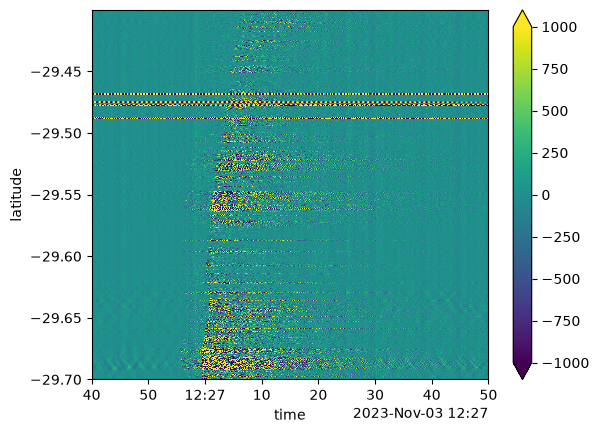

In [20]:
da.plot(x="time", yincrease=True, vmin=-1000, vmax=1000)